In [1]:
import matplotlib.pyplot as plt
import numpy as np
import model as md


# mu = lam2/(2*(1-lam1)**2)
#A FAIRE


### comparaison methode: peut etre un autre fishier  
# fonction cv skearnl 
# comparaison naive/fisher overlap 1D avec mu:cv (peut etre cv sur alpha aussi), overlap vs lambda1 pour diff rho (puis same mais vs lambda2)


### Dans le overleaf:
# C= 1/n [[1, rho][rho, 1]] dans overleaf, 

### si le temps (-> goal absolu):
# comparer fisher theo et empirique, 


In [2]:
def ploplot(title, ylabel, lam_vals, yA, stdA, yB, stdB, ybase=None, stdbase=None):
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.errorbar(lam_vals, yA, yerr=stdA, fmt='o-', capsize=4,
                color='steelblue', label='Method A', linewidth=1.5, markersize=5)
    ax.errorbar(lam_vals, yB, yerr=stdB, fmt='s-', capsize=4,
                color='tomato', label='Method B', linewidth=1.5, markersize=5)

    if ybase is not None:
        ax.errorbar(lam_vals, ybase, yerr=stdbase, fmt='D--', capsize=4,
                    color='gray', label=r'Step1 $\theta_1$', linewidth=1.5, markersize=5)

    ax.axvline(x=1, color='black', linestyle=':', linewidth=1, label=r'$\lambda=1$')
    ax.set_xlabel(r'$\mu$', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()





## Comparaison Fisher théorique évalué avec le signal $x_1$ et notre estimateur $\hat{x}_1$

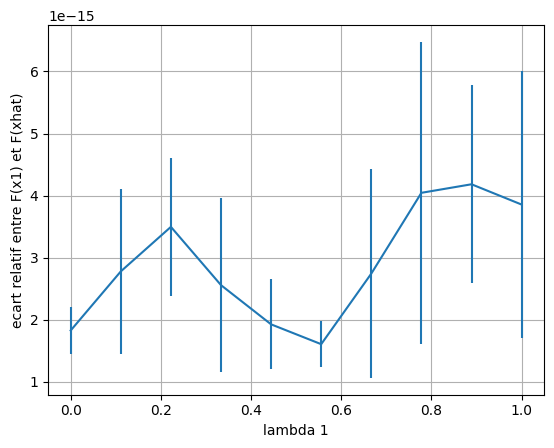

In [2]:

rho = 0.2
RHO = np.linspace(0, 1, 10)

lambda1 = 4
LAM1 = np.linspace(2, 20, 20)

lambda2 = 3

N = 1000
Nvary = np.linspace(500, 5000, 10, dtype = int)

mu = 1
MU = np.linspace(0.1, 100, 20)

M = 10

ecart = []

for rho in RHO:
    ecart += [md.ecart_F_xhat_x1(N, rho, lambda1, lambda2, M=10)]

ecart = np.array(ecart)
plt.errorbar(RHO, ecart[:, 0], ecart[:,1])
plt.grid()
plt.ylabel("ecart relatif entre F(x1) et F(xhat)")
plt.xlabel("lambda 1")
plt.show()

## Résultats pour la methode A et la methode B

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import model as md

def comparison1D(vary_param, val, N, lambda1, lambda2, rho, mu, M=20, method = ["1", "naive", "A"],optimal_mu = False):

    overlaps1 = {m: {"m1": [], "std1": []} for m in method}
    overlaps2 = {m: {"m2": [], "std2": []} for m in method}
    sumover = {m: {"sum": [], "std": []} for m in method}
    normB = []
    stdB = []
    for value in val:
        params = {'N': N, 'lambda1': lambda1, 'lambda2': lambda2, 'rho': rho, 'mu': mu}
        params[vary_param] = value
        m12 = {m: {"m1": [], "m2": []} for m in method}
        norm = []
        print(vary_param,":", value)
        if vary_param != "mu":
            mu_eq = params['lambda2']/(2*(1-params['lambda1'])**2)
            MU = np.linspace(mu_eq - mu_eq/10, mu_eq + mu_eq/10, 15)
            if optimal_mu:
                params['mu'],_, _= md.cv_mu(MU, params['N'], params['rho'], params['lambda1'], params['lambda2'], M= 20,  method = "A", plot = True)
            else:
                params['mu'] = mu_eq

        # print(f"lambda1: {lambda1:.2f}, mu_opt: {mu_opt:.2f}, mu_eq: {mu_eq:.2f}")
        for _ in range(M):
            S = md.TwoSpikes(params['N'], params['lambda1'], params['lambda2'], params['rho'],params['mu'])
            S.compute_method(method)
            nB= np.linalg.norm(S.get_theta("B"))
            for m in method:
                overlap1, overlap2 = S.overlaps(m)
                if m == "B":
                    m12[m]["m1"].append(overlap1/nB)
                    m12[m]["m2"].append(overlap2/nB)
                else:
                    m12[m]["m1"].append(overlap1)
                    m12[m]["m2"].append(overlap2)
            norm.append(nB)
        normB.append(np.mean(norm))
        stdB.append(np.std(norm)/np.sqrt(M))
        
        for m in method:
            overlaps1[m]["m1"].append(np.mean(m12[m]["m1"]))
            overlaps1[m]["std1"].append(np.std(m12[m]["m1"])/np.sqrt(M))
            overlaps2[m]["m2"].append(np.mean(m12[m]["m2"]))
            overlaps2[m]["std2"].append(np.std(m12[m]["m2"])/np.sqrt(M))
            sumover[m]["sum"].append((np.mean(m12[m]["m1"])+ np.mean(m12[m]["m2"]))/2)
            sumover[m]["std"].append((np.std(m12[m]["m1"])+ np.std(m12[m]["m2"]))/2)
    
    return overlaps1, overlaps2, sumover, normB, stdB

rho: 0
mu : 0.01
mu : 0.15142857142857144


c:\Users\celia\Desktop\EPFL\MA2\Physics_project\Spike_code\model.py:154: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  lam = fsolve(norm_constraint, x0=1, args=(A, b, self.N))[0]
c:\Users\celia\Desktop\EPFL\MA2\Physics_project\Spike_code\model.py:154: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  lam = fsolve(norm_constraint, x0=1, args=(A, b, self.N))[0]


mu : 0.29285714285714287
mu : 0.4342857142857143
mu : 0.5757142857142857
mu : 0.7171428571428572
mu : 0.8585714285714285
mu : 1.0


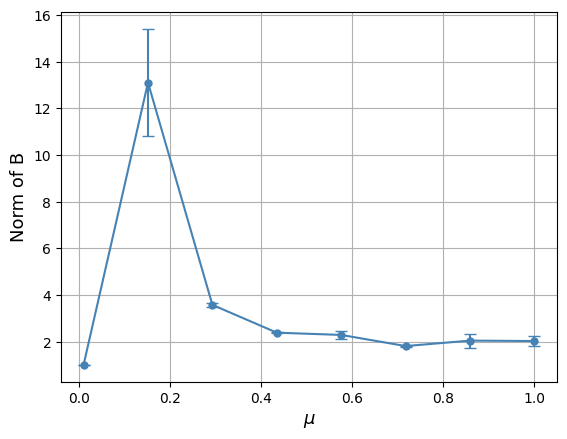

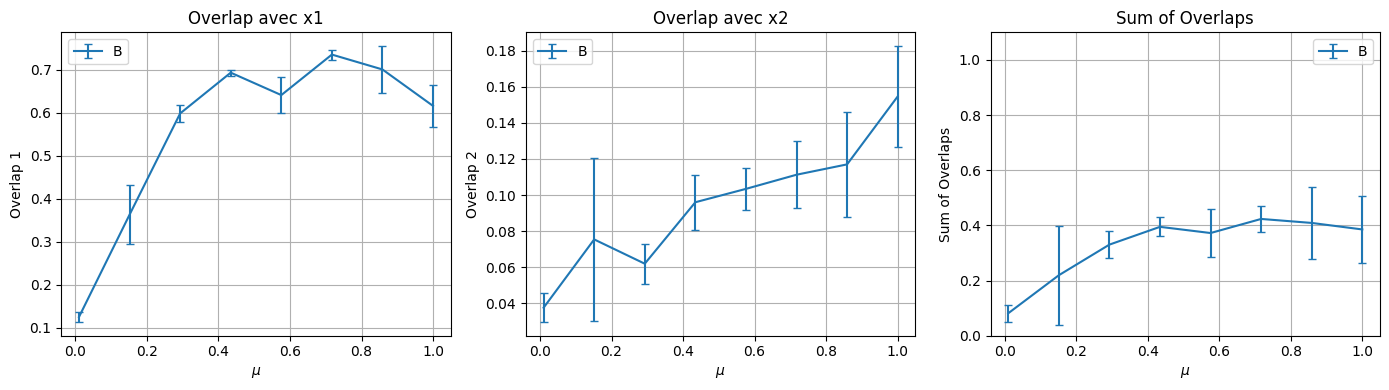

rho: 0.2
mu : 0.01
mu : 0.15142857142857144
mu : 0.29285714285714287
mu : 0.4342857142857143
mu : 0.5757142857142857
mu : 0.7171428571428572
mu : 0.8585714285714285
mu : 1.0


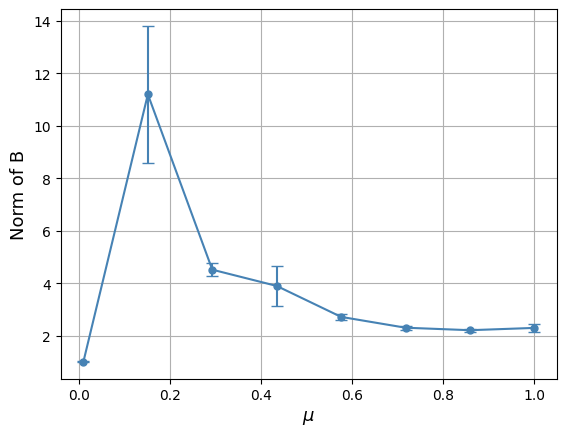

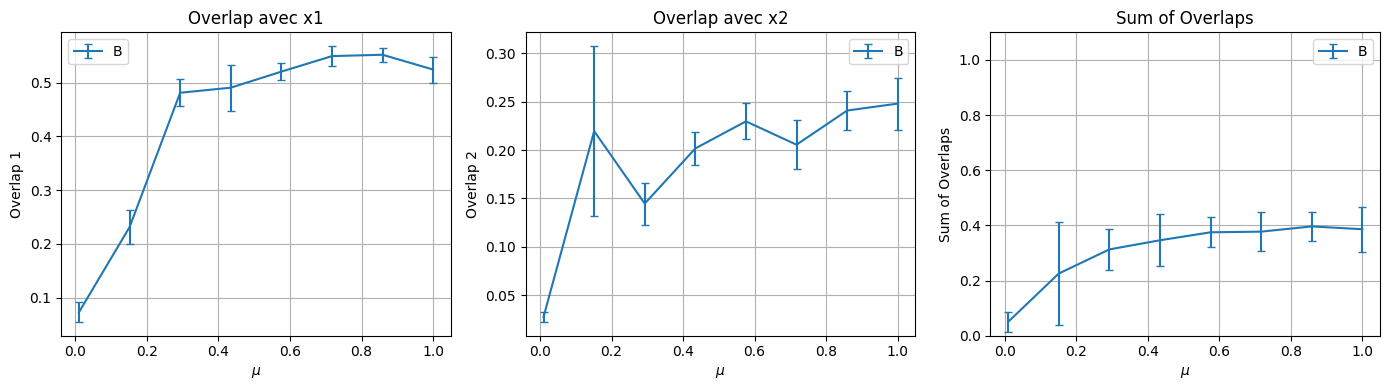

rho: 0.4
mu : 0.01
mu : 0.15142857142857144
mu : 0.29285714285714287


KeyboardInterrupt: 

In [16]:

N =500
lambda2 = 2
lambda1 = 3
mu = 1
MU = np.linspace(0.01, 1, 8)
rho = 0.2
LAM1 = np.linspace(0.1, 5, 20)
M = 10
method = ["B"]
RHO = [0, 0.2, 0.4,0.6, 0.8, 1.0]
# mu_eq = lambda2/(2*(1-lambda1)**2)
# MU = np.linspace(mu_eq - mu_eq/10, mu_eq + mu_eq/10, 15)
for rho in RHO:
    print(f"rho: {rho}")
    overlaps1, overlaps2, sumover, normB, stdB = comparison1D(vary_param="mu", val=MU, N=N, lambda1=lambda1, lambda2=lambda2, rho=rho, mu=mu, M=10, method=method)
    
    plt.errorbar(MU, normB, yerr=stdB, fmt='o-', capsize=4,
                color='steelblue', label='Norm of B', linewidth=1.5, markersize=5)
    plt.grid()
    plt.xlabel(r'$\mu$', fontsize=13)
    plt.ylabel('Norm of B', fontsize=13)
    plt.show()
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Plot overlap 1
    ax = axes[0]

    for m in method:
        ax.errorbar(
            MU,
            overlaps1[m]["m1"],
            yerr=overlaps1[m]["std1"],
            label=m,
            capsize=3
        )

    ax.set_xlabel(r'$\mu$')
    ax.set_ylabel('Overlap 1')
    ax.set_title('Overlap avec x1')
    ax.legend()
    ax.grid()


    # Plot overlap 2
    ax = axes[1]

    for m in method:
        ax.errorbar(
            
            MU,
            overlaps2[m]["m2"],
            yerr=overlaps2[m]["std2"],
            label=m,
            capsize=3
        )

    ax.set_xlabel(r'$\mu$')
    ax.set_ylabel('Overlap 2')
    ax.set_title('Overlap avec x2')
    ax.legend()
    ax.grid()

    ax = axes[2]

    for m in method:
        ax.errorbar(
            MU,
            sumover[m]["sum"],
            yerr=sumover[m]["std"],
            label=m,
            capsize=3
        )

    ax.set_xlabel(r'$\mu$')
    ax.set_ylabel('Sum of Overlaps')
    ax.set_title('Sum of Overlaps')
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid()


    plt.tight_layout()
    plt.show()

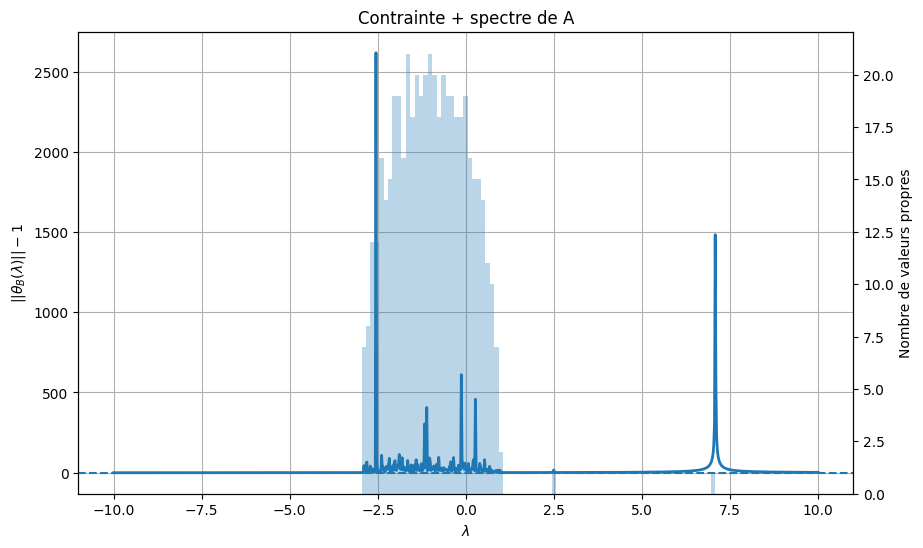

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# Paramètres
# ===========================

N = 500
lambda1 = 3
lambda2 = 3
rho = 0
mu = 1

# ===========================
# Construire A et b
# ===========================

S = md.TwoSpikes(
    N,
    lambda1,
    lambda2,
    rho,
    mu=mu
)

S.compute_theta1()

F1 = S.fisher_MS(
    S.get_theta("1"),
    lambda1
)

A = (
    S.Y2
    - np.eye(N)
    + 2 * mu * F1
)

b = (
    2
    * mu
    * F1
    @ S.get_theta("1")
)

# ===========================
# Calcul f(lambda)
# ===========================

LAM = np.linspace(-10, 10, 1000) #!!! ESSAYER sur intervalle sans vp pour voir si coupe vraiment zero oou flucture

vals = []

for lam in LAM:

    try:
        vals.append(
            md.norm_constraint(
                lam,
                A,
                b,
                N
            )
        )

    except np.linalg.LinAlgError:
        vals.append(np.nan)

vals = np.array(vals)

# ===========================
# Valeurs propres
# ===========================

eig = np.linalg.eigvalsh(A)

# ===========================
# Plot
# ===========================

fig, ax1 = plt.subplots(
    figsize=(10, 6)
)

# Courbe contrainte

ax1.plot(
    LAM,
    vals,
    linewidth=2,
    label=r"$||\theta_B||-1$"
)

ax1.axhline(
    0,
    linestyle="--"
)

ax1.set_xlabel(r"$\lambda$")
ax1.set_ylabel(
    r"$||\theta_B(\lambda)||-1$"
)

ax1.grid()

# Histogramme VP

ax2 = ax1.twinx()

ax2.hist(
    eig,
    bins=80,
    alpha=0.3,
    density=False
)

ax2.set_ylabel(
    "Nombre de valeurs propres"
)

plt.title(
    "Contrainte + spectre de A"
)

plt.show()

## Analyse de la Hessienne et Fisher (det et spectre)

0.14


c:\Users\celia\Desktop\EPFL\MA2\Physics_project\venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\celia\Desktop\EPFL\MA2\Physics_project\venv\Lib\site-packages\numpy\lib\_histograms_impl.py:853: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
c:\Users\celia\Desktop\EPFL\MA2\Physics_project\venv\Lib\site-packages\matplotlib\axes\_axes.py:7135: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16
c:\Users\celia\Desktop\EPFL\MA2\Physics_project\venv\Lib\site-packages\numpy\ma\core.py:3452: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


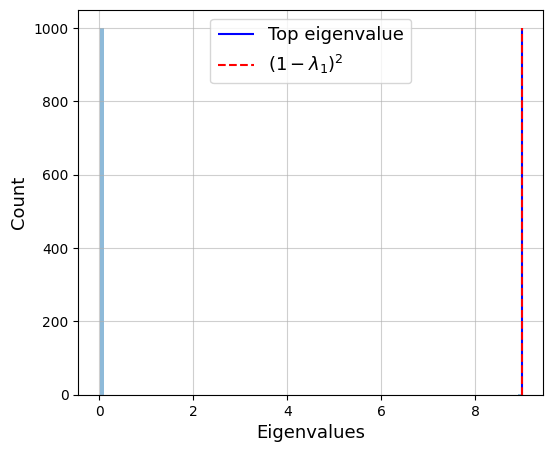

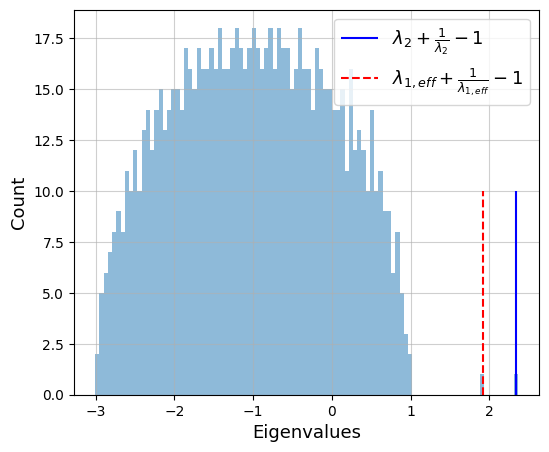

0.15


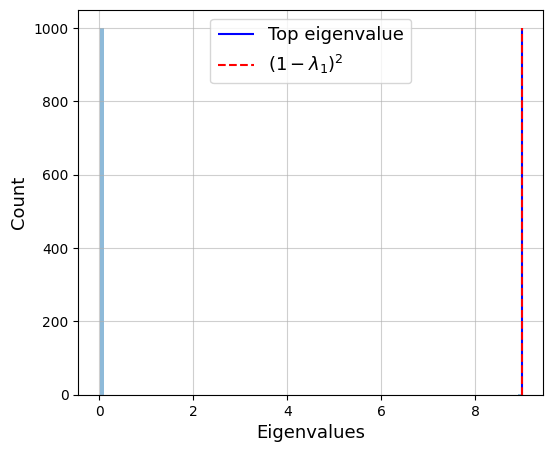

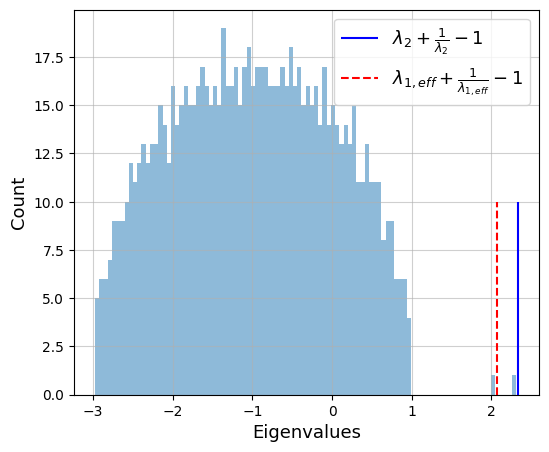

0.16666666666666666


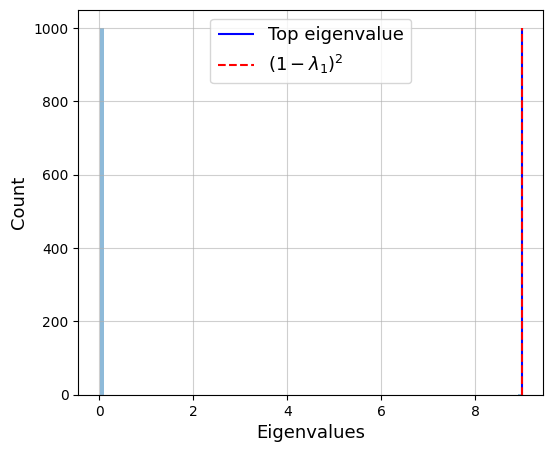

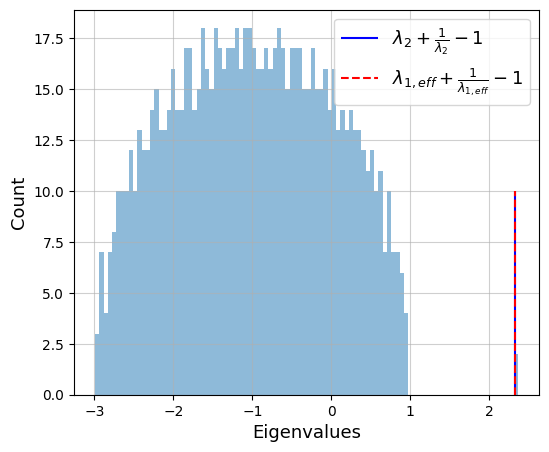

0.18


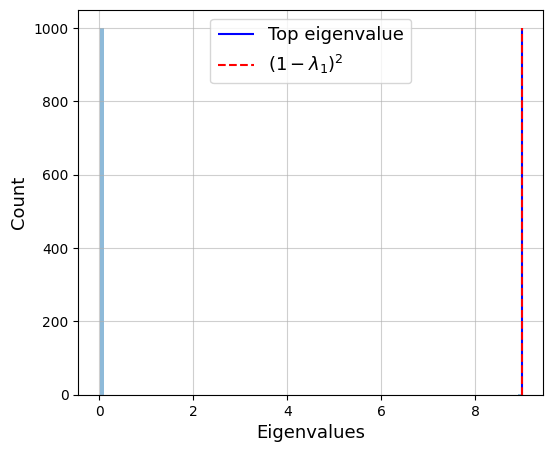

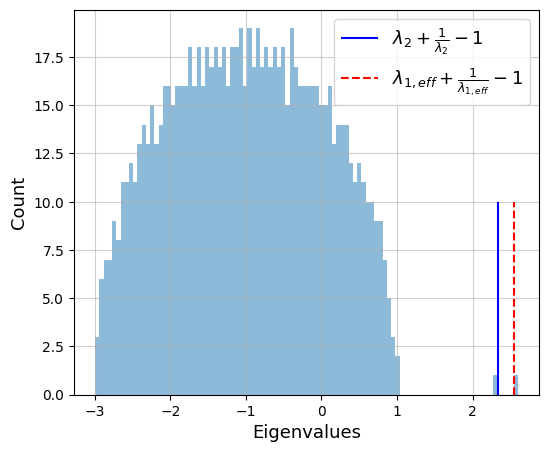

0.19


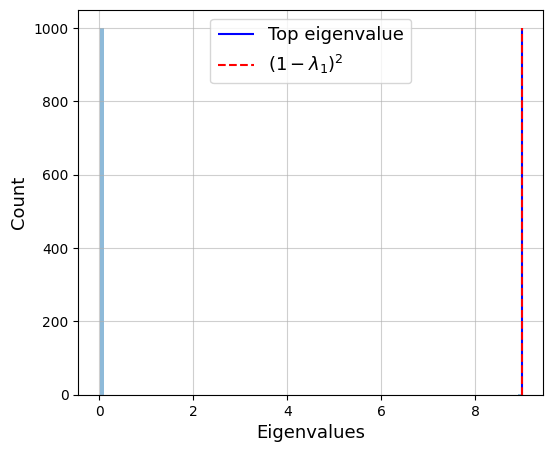

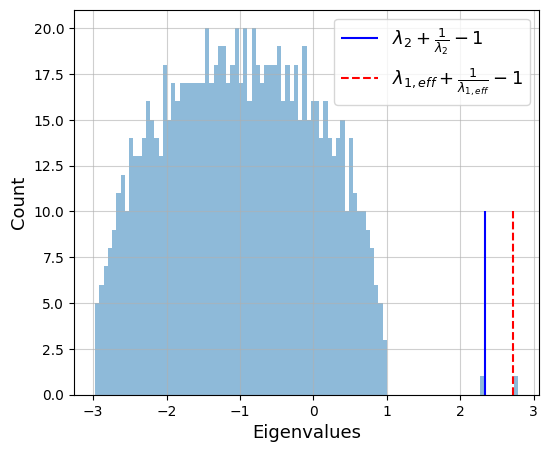

In [5]:
## HESS LAMBDA1 > LAMBDA2

N = 1000

mu = 1
rho = 0
MU = np.array([0.14, 0.15, 1/6, 0.18, 0.19])

for mu in MU:
    print(mu)
    lambda2 = 3
    lambda1 = 4
    md.analyse_Hess_Fisher(N, rho, lambda1, lambda2, mu, estim = False,  spectre = True)




[np.float64(4.429245374106294e-52), np.float64(9.794853061082954e-76), np.float64(7.5469784936309e-106), np.float64(3.7151208498268505e-130), np.float64(-6.597533768921393e-156), np.float64(1.4084594657441347e-181), np.float64(6.840089114287933e-207), np.float64(-1.602380521487758e-231), np.float64(1.2981937093736382e-259), np.float64(-1.2024376754631506e-283), np.float64(9.108649144174e-311), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(0.0), np.float64(-0.0), np.float64(-0.0)]


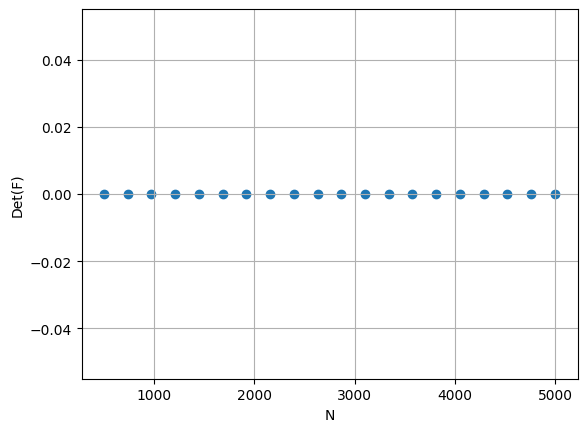

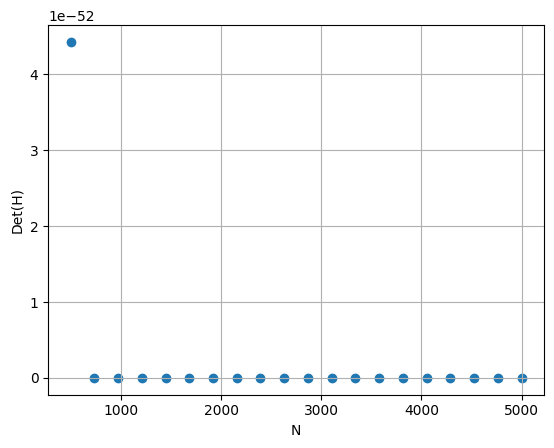

In [8]:
Nvary = np.linspace(500, 5000, 20, dtype = int)
lambda2 = 8
lambda1 = 7
mu = 1
MU = np.linspace(0.1, 50, 20)
rho = 0.7
LAM1 = np.linspace(0.1, 5, 20)
M = 10
N = 1000
RHO = np.linspace(0, 1, 5)
DETF= []
DETH= []
for N in Nvary: 
    detF, detH = md.analyse_Hess_Fisher(N, rho, lambda1, lambda2, mu, spectre = False)
    DETF += [detF]
    DETH += [detH]
print(DETH)
DETF = np.array(DETF)
DETH = np.array(DETH)


plt.scatter(Nvary, DETF)
plt.xlabel("N")
plt.ylabel("Det(F)")
plt.grid()
plt.show()

plt.scatter(Nvary, DETH)
plt.xlabel("N")
plt.ylabel("Det(H)")
plt.grid()
plt.show()

## Overlapp 2D pour la methode A

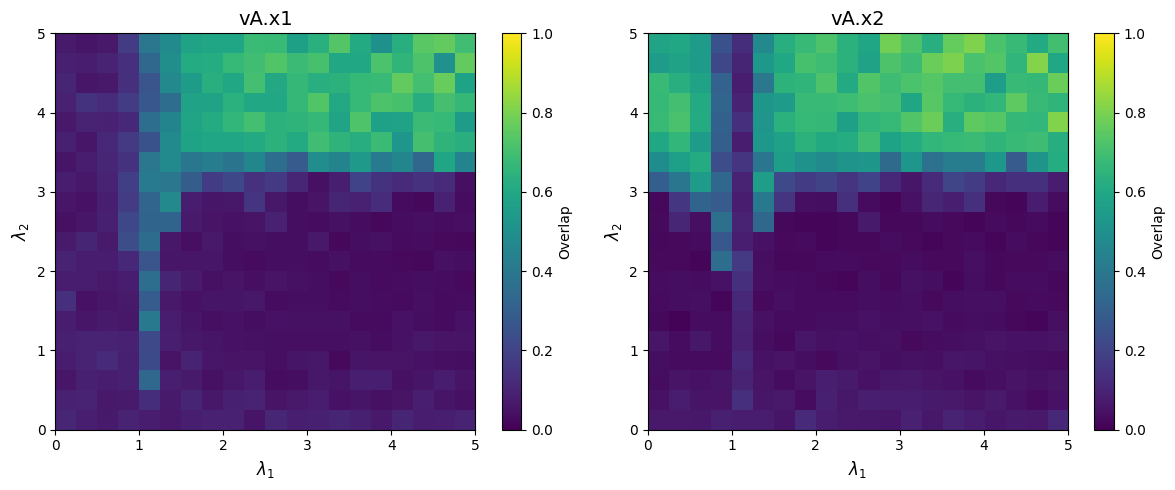

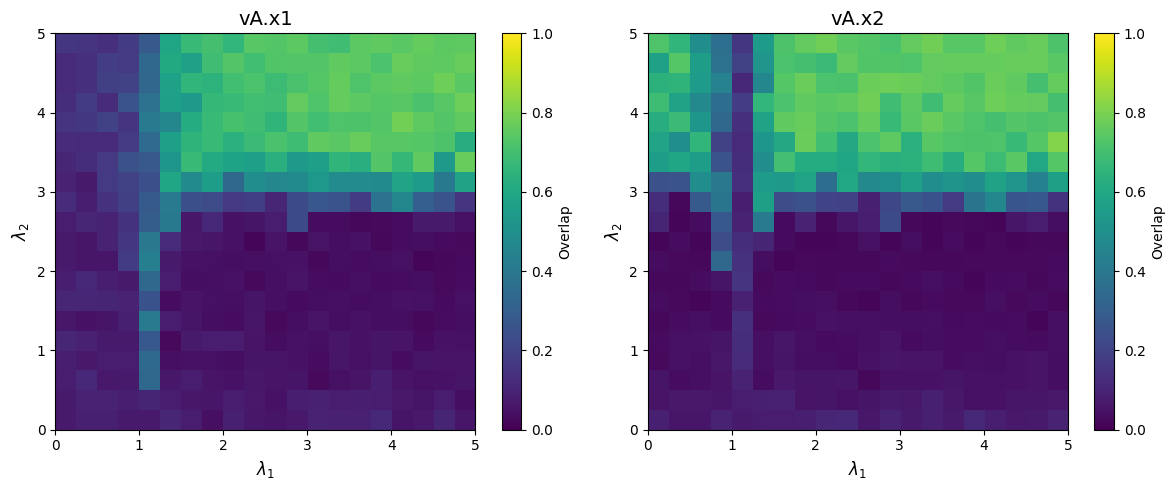

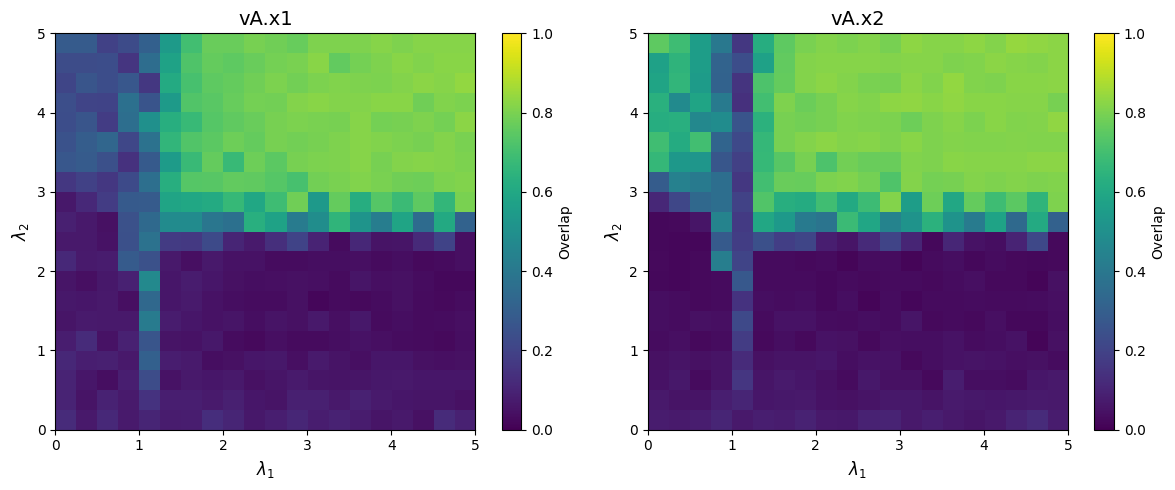

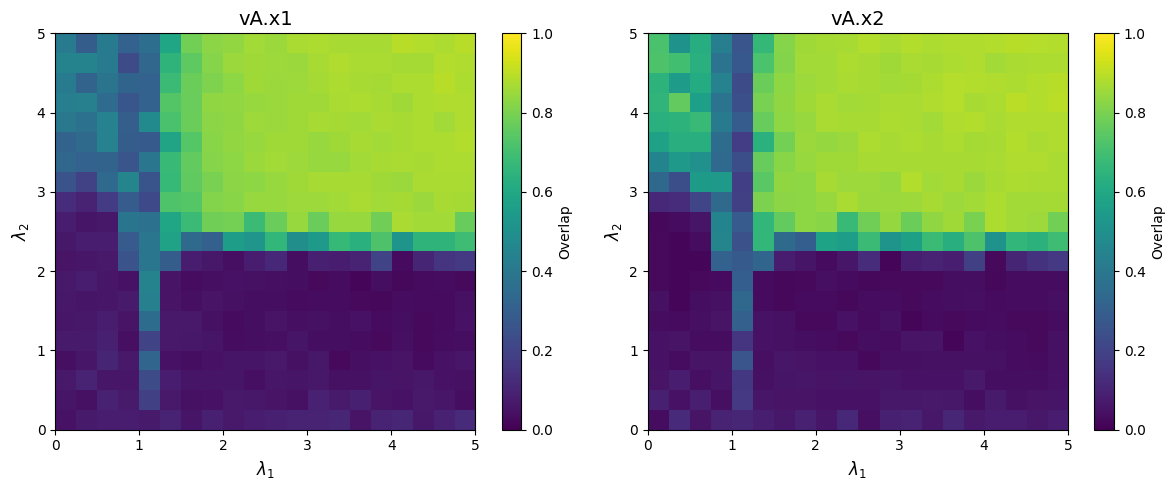

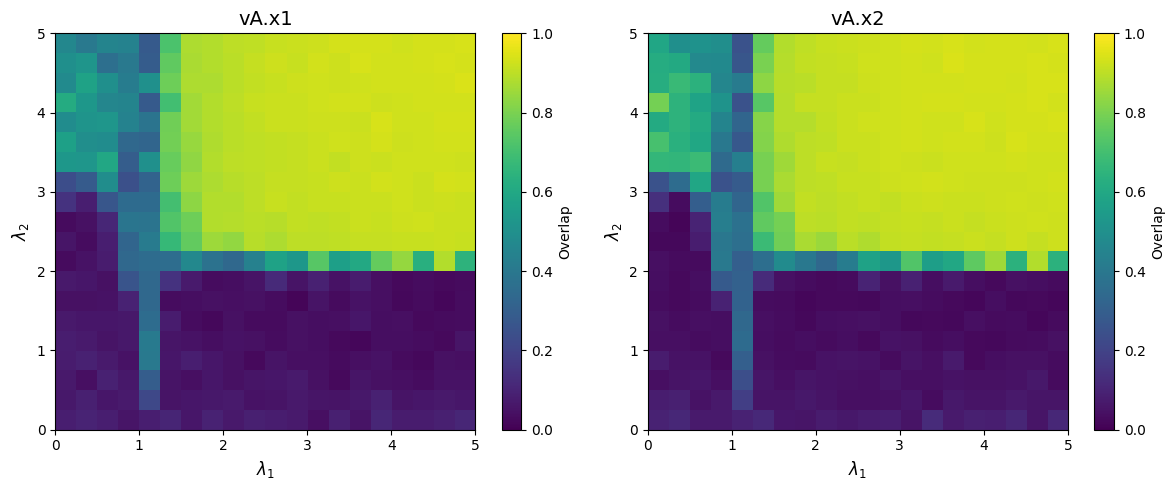

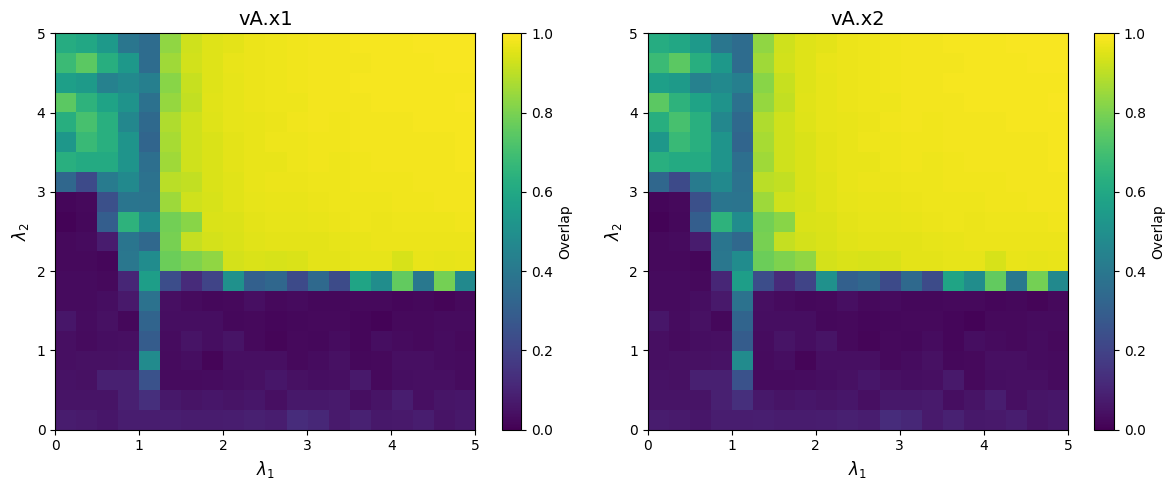

In [9]:

M=10 #nb of simulation for averaging (precision)
n=100 #size of signal
k1= 3
k2= 10

rho = 0.2

RHO = np.linspace(0,1,6)
K1 = np.linspace(0,5,20)
K2 = np.linspace(0,5,20)
MU = np.linspace(0,1, 20)


##PLOT

for rho in RHO:
    ZA1, ZB2, ZA2, ZB1 = md.run_experiment_2D(vary_param_x='k1', vary_values_x = K1, 
                                        vary_param_y = 'k2', vary_values_y = K2,
                                        M = M, n = n , k1 = k1, k2 = k2, 
                                        rho = rho , 
                                        method = "fisher", methodF = "A",
                                        all_overlap = True, plot = False, mu_opt = True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes = axes.flatten()
    titles = ['vA.x1', 'vA.x2']
    Zs = [ZA1, ZA2]

    mu_opt = K2/(2*(1-k1)**2)

    for ax, Z, title in zip(axes, Zs, titles):
        im = ax.imshow(Z, origin='lower', aspect='auto', cmap='viridis',
                            extent=[K1[0], K1[-1], 
                                    K2[0], K2[-1]],vmin=0, vmax=1)
        
        fig.colorbar(im, ax=ax, label='Overlap')
        ax.set_xlim(K1[0], K1[-1])
        ax.set_ylim(K2[0], K2[-1])
        ax.set_xlabel(r"$\lambda_1$", fontsize=12)
        ax.set_ylabel(r"$\lambda_2$", fontsize=12)
        ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()